## **Project Name : Crop Recommendation System**

### **Problem Statement :**

Agriculture productivity depends heavily on soil nutrients and environmental conditions. Farmers often struggle to select the most suitable crop based on soil composition (N, P, K), temperature, humidity, pH, and rainfall.

The goal of this project is to build a Machine Learning model that recommends the most suitable crop based on these input parameters to improve agricultural decision-making.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [32]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [3]:
df.shape

(2200, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [10]:
df.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

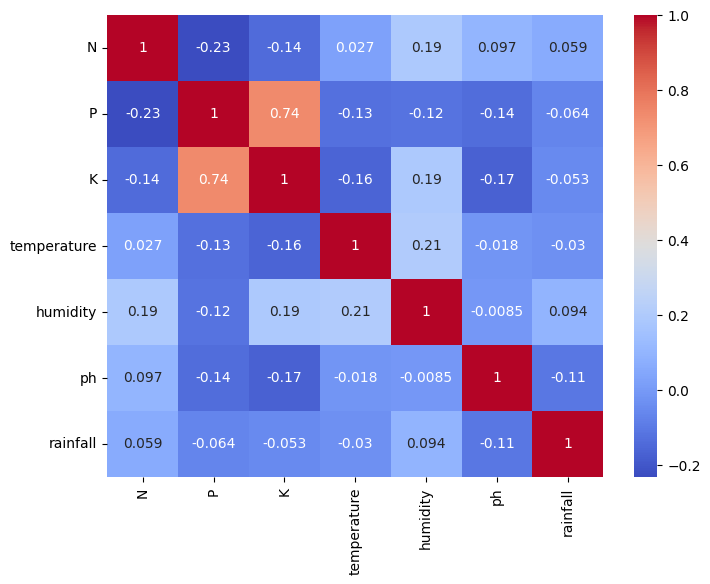

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('label', axis=1).corr(), 
            annot=True, 
            cmap='coolwarm')
plt.show()


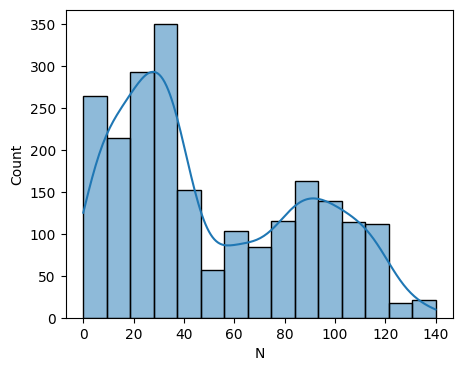

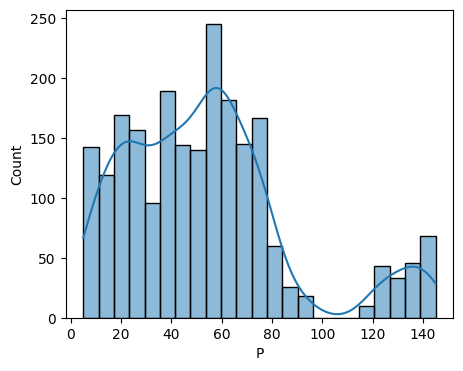

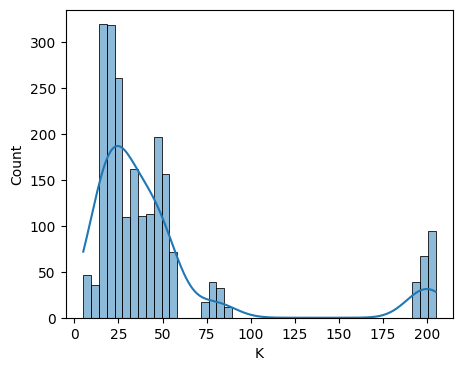

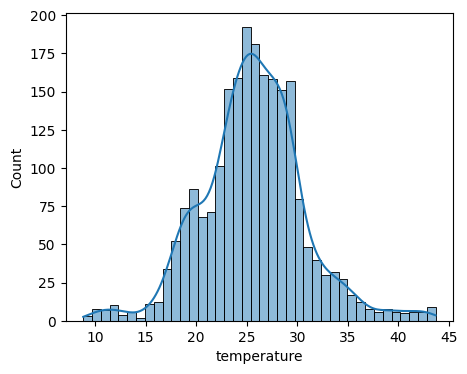

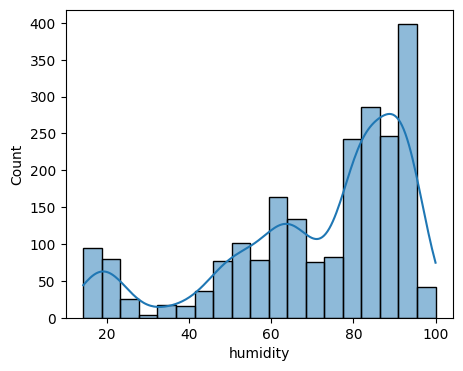

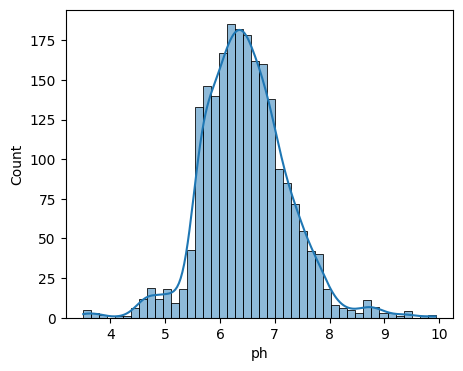

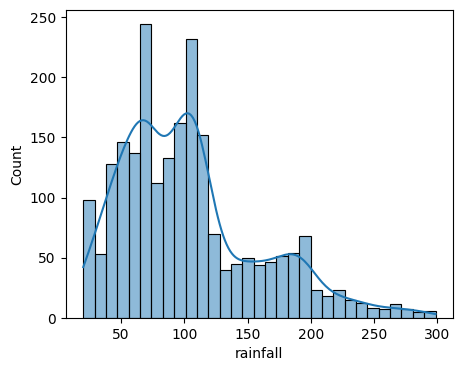

In [5]:
column=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for col in column :
    plt.figure(figsize=(5,4))
    sns.histplot(df[col],kde=True)

### **Label Encoding**

In [6]:
le=LabelEncoder()
df['label']=le.fit_transform(df['label'])

In [50]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [7]:
df.label.value_counts()

label
20    100
11    100
3     100
9     100
18    100
13    100
14    100
2     100
10    100
19    100
1     100
12    100
7     100
21    100
15    100
0     100
16    100
17    100
4     100
6     100
8     100
5     100
Name: count, dtype: int64

In [8]:
x=df.drop('label',axis=1)
y=df['label']

In [9]:
x.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [10]:
y.head()

0    20
1    20
2    20
3    20
4    20
Name: label, dtype: int64

In [11]:
X_train,X_test,Y_train,Y_test =train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
X_train.shape

(1760, 7)

In [13]:
from sklearn.preprocessing import MinMaxScaler
mx =MinMaxScaler()
X_train =mx.fit_transform(X_train)
X_test=mx.transform(X_test)


In [14]:
X_train

array([[0.        , 0.09285714, 0.045     , ..., 0.90697247, 0.5759011 ,
        0.33844189],
       [0.06428571, 0.83571429, 0.98      , ..., 0.77762857, 0.32121765,
        0.17191702],
       [0.07857143, 0.47142857, 0.095     , ..., 0.09869129, 0.32686741,
        0.43612325],
       ...,
       [0.58571429, 0.30714286, 0.155     , ..., 0.78754059, 0.44279543,
        0.62163207],
       [0.64285714, 0.32142857, 0.195     , ..., 0.69092242, 0.4274513 ,
        0.54342014],
       [0.00714286, 0.90714286, 0.975     , ..., 0.80123177, 0.32906407,
        0.16656566]], shape=(1760, 7))

In [15]:
from sklearn.preprocessing import StandardScaler
sc =StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test=sc.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [17]:
models= {
    'LogisticRegression':LogisticRegression(),
    'SVC':SVC(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier()
}

In [18]:
for name,model in models.items():
    model.fit(X_train,Y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(Y_test,y_pred)
    print(f"{name} model with accuracy :{score}")

LogisticRegression model with accuracy :0.9727272727272728
SVC model with accuracy :0.9840909090909091
KNeighborsClassifier model with accuracy :0.9795454545454545
DecisionTreeClassifier model with accuracy :0.9795454545454545
RandomForestClassifier model with accuracy :0.9931818181818182


In [20]:
rf = RandomForestClassifier()
rf.fit(X_train,Y_train)
y_pred= rf.predict(X_test)
accuracy_score(Y_test,y_pred)

0.9931818181818182

In [21]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [22]:
def recommendation(N,P,K,temperature,humidity,ph,rainfall):
    features=np.array([[N,P,K,temperature,humidity,ph,rainfall]])
    mx_features=mx.transform(features)
    sc_mx_features=sc.transform(mx_features)
    prediction=rf.predict(sc_mx_features).reshape(1,-1)
    return prediction[0]

In [23]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [24]:
N = 90
P = 50
K=  60
temperature = 45.1
humidity = 50
ph=  6
rainfall= 100
predict=recommendation(N,P,K,temperature,humidity,ph,rainfall)

c:\Users\Vinayak N\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [25]:
predict

array([5])

In [27]:
import pickle
pickle.dump(rf,open('model.pkl','wb'))
pickle.dump(mx,open('minmaxscalar.pkl','wb'))
pickle.dump(sc,open('standardscalar.pkl','wb'))
pickle.dump(le, open("label_encoder.pkl", "wb"))

In [28]:
cm= confusion_matrix(Y_test,y_pred)

In [36]:
cm.shape

(22, 22)

In [31]:
cr=classification_report(Y_test,y_pred)
print("\n",cr)


               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00  

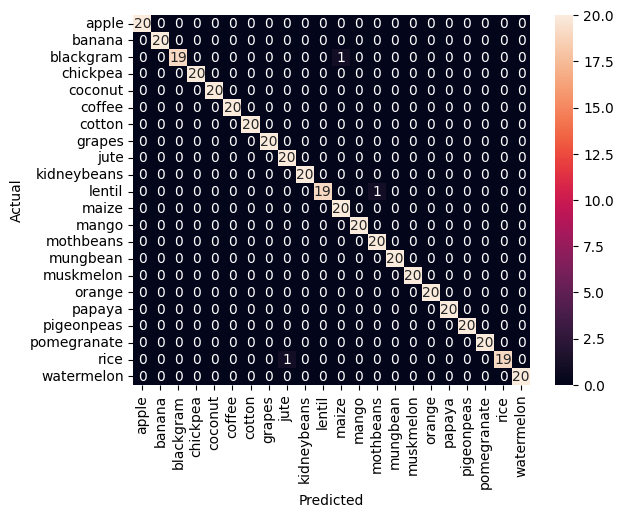

In [30]:
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
